# The HR diagram

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format='retina'

from sklearn.decomposition import PCA

In [2]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x125aca350>)

In [3]:
df_stars = pd.read_csv("stars.csv")

Data contains properties of stars, according to 4 features:
- Temperature
- Luminosity
- Radius
- Absolute Magnitude

Data contains also labels (Star types), which we will convert to numbers from 0 to 6

In [4]:
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels=df_stars['Star type'].to_numpy()

star_type = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_

In [6]:
def discrete_cmap(N, base_cmap=None):
    """Create an N-bin discrete colormap from the specified input map"""
    base = plt.colormaps[base_cmap]
    color_list = base(np.linspace(0, 1, N))
    cmap_name = base.name + str(N)
    return base.from_list(cmap_name, color_list, N)

Quick data visualization

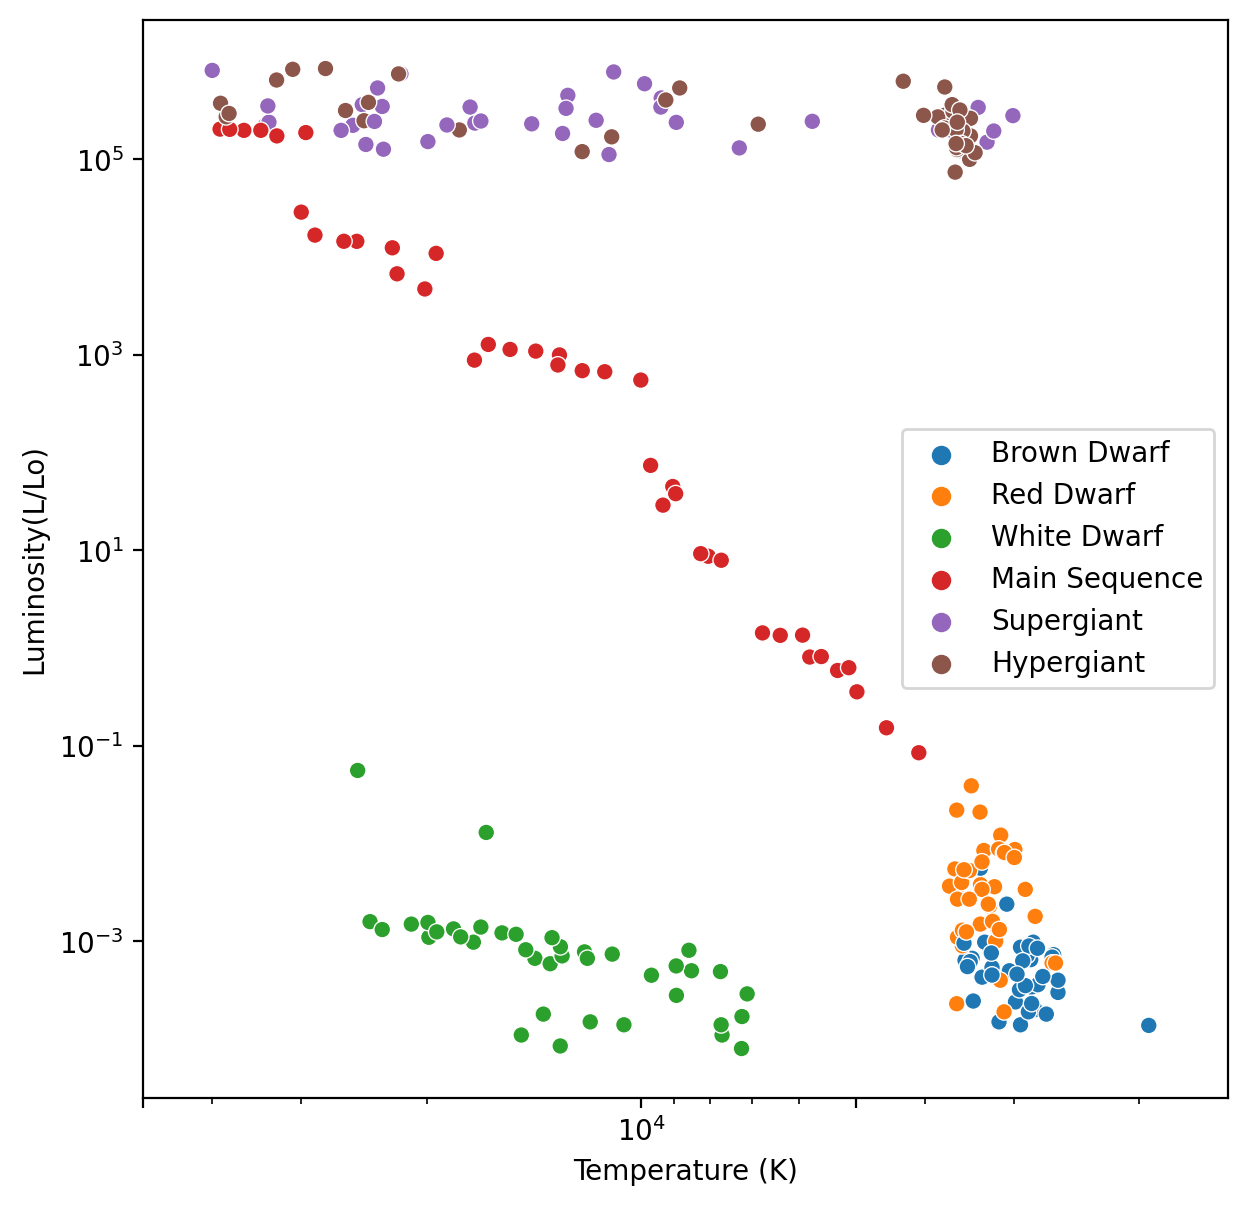

In [7]:
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=star_type)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

Some classes are clearly separated from others (in this L vs T plot + colors for labels) but some others are not, so we would like to perform a dimensionality reduction: from 4 features we want to project our data to 2 components. 

In [8]:
data=pd.read_csv("stars.csv", usecols=["Temperature (K)","Luminosity(L/Lo)","Radius(R/Ro)","Absolute magnitude(Mv)"])
X=data.to_numpy()

I will use PCA with 2 components

In [9]:
pca = PCA(n_components=2) 
projected_X=pca.fit_transform(X) 

eigenvalues = pca.transform(X) 
mean = pca.mean_ 
eigenvectors = pca.components_

In [10]:
print(eigenvalues.shape)
print(eigenvectors.shape)

(240, 2)
(2, 4)


In [11]:
evals = pca.explained_variance_ratio_ 
print('Expained variance: ' + str(evals))

Expained variance: [0.99760631 0.0023879 ]


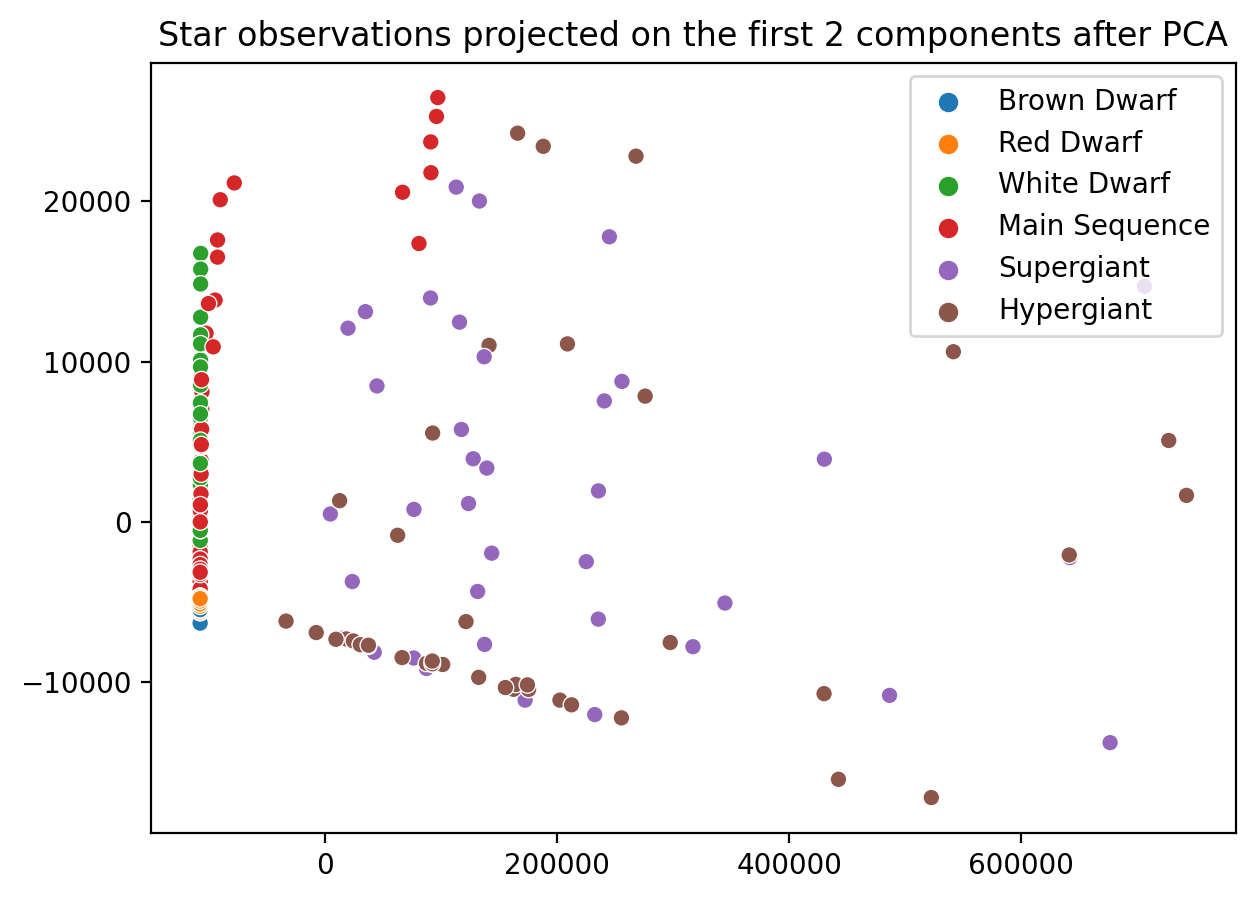

In [12]:
fig = plt.figure(figsize=(7, 5))
sns.scatterplot(x=projected_X[:,0], y=projected_X[:,1], hue=star_type)
plt.title("Star observations projected on the first 2 components after PCA")

plt.show()

This is a bad result because I didn't scale my data to zero mean and unit variance before PCA

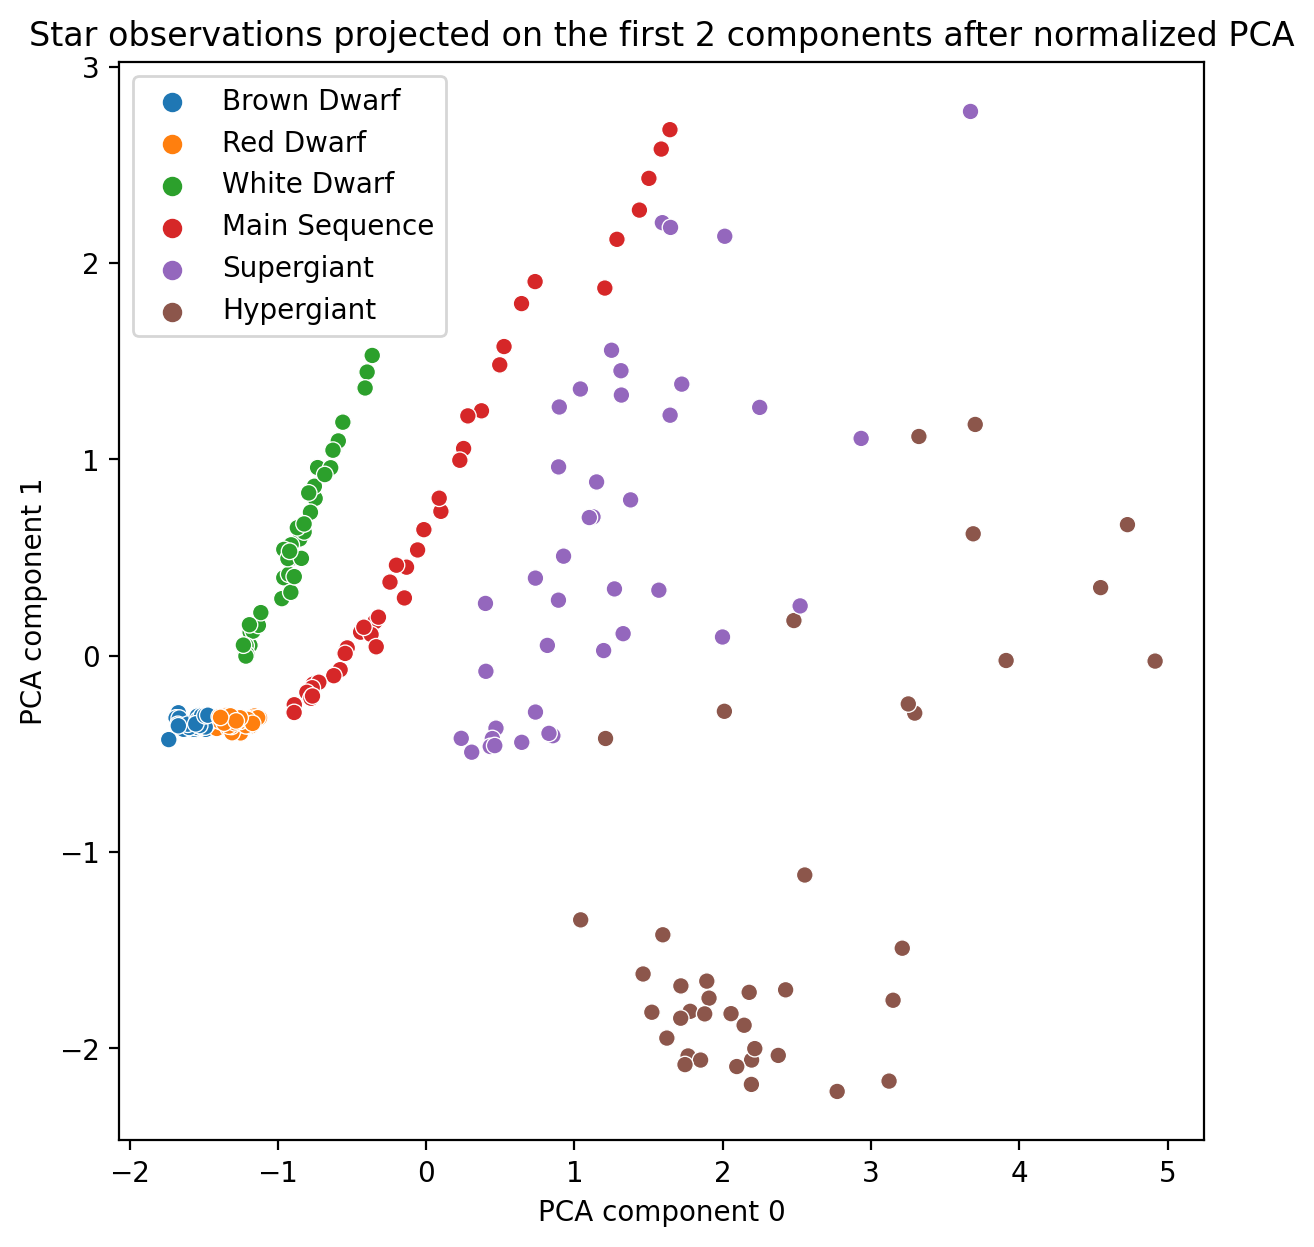

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

pca = PCA(n_components=2)
projected_stars = pca.fit_transform(X)

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(x=projected_stars[:,0], y=projected_stars[:,1], hue=star_type)
plt.xlabel("PCA component 0")
plt.ylabel("PCA component 1")

plt.title("Star observations projected on the first 2 components after normalized PCA")
plt.show()

This is way better and all classes (with data projected on two components) are clearly separated

In [14]:
evals = pca.explained_variance_ratio_ 
print('Expained variance: ' + str(evals))

Expained variance: [0.60357391 0.23500784]
